In [20]:
import sys
import logging
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Importing necessary modules for data loading and transformation
from data_loader import DASDataLoader, fft

logging.basicConfig(level=logging.INFO)

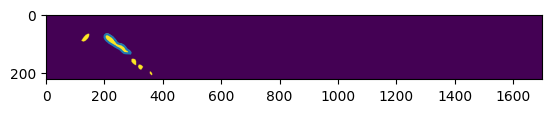

In [21]:
import json
from pprint import pprint

with open("/nobackup/carda/datasets/DAS-dataset/data/car/auto2_2023-04-17T124510+0100.json") as f:
    data_points = json.load(f)

# pprint(data_points.keys())
# pprint(data_points['curve0'])

# Load data from numpy file
data = np.load("/nobackup/carda/datasets/DAS-dataset/data/car/auto2_2023-04-17T124510+0100.npy", allow_pickle=True)
# pprint(data)
plt.imshow(data)
x_points = data_points['curve0']['x']
y_points = data_points['curve0']['y']

plt.plot(x_points, y_points)  # Draw shape by connecting points

plt.show()


In [22]:
decim_dict = {
    # The 'regular' label will be decimated by a factor of 50
    'regular': 50,
}

# Initializing the DASDataLoader with dataset parameters
parser = DASDataLoader(
    '/nobackup/carda/datasets/DAS-dataset/data',  # Path to the dataset directory
    2048,  # Sample length
    transform=fft,  # Applying FFT as a preprocessing step
    fsize=8192,  # Window size for sliding window segmentation
    # Step size for the sliding window (overlap of 75% with fsize=8192)
    shift=2048,
    # Dictionary specifying the decimation factor for each label
    decimate=decim_dict,
)


In [23]:
# Parsing the dataset into features (x) and labels (y)
x, y = parser.parse_dataset()

# Output parsed dataset details
print(x, y)
print(f'The dataset contains {len(x)} elements')

INFO:data_loader:Parsing dataset for label [fence]...
INFO:data_loader:Parsing dataset for label [car]...
INFO:data_loader:Parsing dataset for label [walk]...
INFO:data_loader:Parsing dataset for label [manipulation]...
INFO:data_loader:Parsing dataset for label [longboard]...
INFO:data_loader:Parsing dataset for label [regular]...
INFO:data_loader:Parsing dataset for label [construction]...
INFO:data_loader:Parsing dataset for label [running]...
INFO:data_loader:Parsing dataset for label [openclose]...
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/running/running_2023-04-17T122413+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/longboard/longboardroad_2023-04-17T123638+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/fence/kopani_plot_2023-11-07T150207Z.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/walk/walking2_2023-04-17T122153+0100.h5
INFO:data_loade

[[5.6094537 5.097933  4.700012  ... 4.093706  4.3315716 4.1064677]
 [5.5273185 5.331628  5.296272  ... 4.318819  3.751658  4.4795156]
 [4.66952   4.5801835 4.461422  ... 4.1655807 4.2454867 4.2480106]
 ...
 [6.2491736 6.4206333 6.8543096 ... 4.094826  3.808321  3.705519 ]
 [5.9568806 5.6151996 6.0756884 ... 3.258548  4.094016  4.209584 ]
 [4.4336452 4.881655  4.991021  ... 4.2888474 3.7518768 4.1855836]] [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
The dataset contains 118642 elements


In [24]:
x.shape
# x = x[:, np.newaxis, :]
# x.shape


(118642, 2048)

In [40]:
full_mean = np.mean(x, axis=0, keepdims=True)
full_std = np.std(x, axis=0, keepdims=True) + 1e-8
x_normalized = (x - full_mean) / full_std
x_normalized.shape


(118642, 2048)

In [25]:
for i, name, weight in zip(range(len(parser.encoder.classes_)), parser.encoder.classes_, parser.class_weights):
    print(f'{i}: {name:<15} - {weight}')

0: car             - 0.6290234501333418
1: construction    - 0.4519333691399926
2: fence           - 3.66179012345679
3: longboard       - 1.1070242227447467
4: manipulation    - 0.7653976917171482
5: openclose       - 2.218146465496289
6: regular         - 3.137930122457616
7: running         - 1.0197605356574955
8: walk            - 1.0368447730410921


In [26]:
y.argmax(axis=1)
Y = y.argmax(axis=1)
Y.shape

(118642,)

In [27]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


In [28]:
def get_device():
    """Detect and return best available device (MPS > CUDA > CPU)"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon (MPS)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

In [29]:
class SimilarityDataset(Dataset):
    def __init__(self, x, y, pairs_per_sample=2, seed=42):
        self.x = torch.FloatTensor(x)
        self.y = torch.LongTensor(y)
        self.pairs_per_sample = pairs_per_sample
        self.seed = seed
        self.rng = np.random.RandomState(seed)
        self.class_indices = {c: np.where(self.y == c)[0] for c in np.unique(self.y)}
        
    def __len__(self):
        return len(self.x) * self.pairs_per_sample
    
    def __getitem__(self, idx):
        anchor_idx = idx % len(self.x)
        anchor_sample = self.x[anchor_idx]
        anchor_label = self.y[anchor_idx].item()

        if self.rng.rand() < 0.5:
            positive_idx = self.rng.choice(self.class_indices[anchor_label])
            pair = self.x[positive_idx]
            similarity_label = 1.0
        else:
            # Randomly select a different class
            negative_classes = [c for c in self.class_indices.keys()
                               if c != anchor_label]
            negative_class = self.rng.choice(negative_classes)
            positive_idx = self.rng.choice(self.class_indices[negative_class])
            pair = self.x[positive_idx]
            similarity_label = 0.0
    
        return anchor_sample, pair, torch.FloatTensor([similarity_label])

In [44]:
dataset = SimilarityDataset(x, Y)
dataset[0]

(tensor([5.6095, 5.0979, 4.7000,  ..., 4.0937, 4.3316, 4.1065]),
 tensor([6.0690, 6.0717, 5.9992,  ..., 4.2231, 4.2040, 4.3018]),
 tensor([1.]))

In [45]:
class EmbeddingNetwork(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super(EmbeddingNetwork, self).__init__()
        self.embedding_dim = embedding_dim
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, embedding_dim),
        )
    
    def forward(self, x):
        return self.network(x)
    

In [46]:
class EmbeddingConvNetwork(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super(EmbeddingConvNetwork, self).__init__()
        self.embedding_dim = embedding_dim
        self.network = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, stride=1, padding=0),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=4),
            nn.Conv1d(64, 256, kernel_size=7, stride=1, padding=0),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=4),
            nn.Flatten(),
            nn.Linear(256 * 126, 1024),
            nn.ReLU(),
            nn.Linear(1024, embedding_dim),
        )
    
    def forward(self, x):
        # Reshape input from [batch, features] to [batch, channels, length]
        # Conv1d expects [batch, channels, length], so we add a length dimension
        # if x.dim() == 2:
        #     x = x.unsqueeze(-1)  # [batch, 2048] -> [batch, 2048, 1]
        if x.dim() == 2:
            x = x.unsqueeze(1)
            
        # Case 2: Input is (Batch, Length, 1) -> Permute to (Batch, 1, Length)
        # Some datasets put channels last; PyTorch needs channels second.
        elif x.dim() == 3 and x.shape[2] == 1:
            x = x.permute(0, 2, 1)
        return self.network(x)

embedding_conv_net = EmbeddingConvNetwork(input_dim=2048, embedding_dim=128)

print(embedding_conv_net)


EmbeddingConvNetwork(
  (network): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 256, kernel_size=(7,), stride=(1,))
    (4): LeakyReLU(negative_slope=0.01)
    (5): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=32256, out_features=1024, bias=True)
    (8): ReLU()
    (9): Linear(in_features=1024, out_features=128, bias=True)
  )
)


In [47]:
class SimilarityHead(nn.Module):
    def __init__(self, embedding_network):
        super(SimilarityHead, self).__init__()

        # Learnable weights for different similarity measures
        self.similarity_weights = nn.Parameter(torch.ones(embedding_network.embedding_dim + 3) / 4)  # Equal initial weights

        # Learnable transformation for each similarity measure
        self.l1_transform = nn.Linear(1, 1)
        self.l2_transform = nn.Linear(1, 1)
        self.element_wise_transform = nn.Linear(embedding_network.embedding_dim, 1)
        self.cosine_transform = nn.Linear(1, 1)

        # Final combination layer
        self.combination_layer = nn.Linear(embedding_network.embedding_dim + 3, 1)

    def forward(self, embedding_1, embedding_2):
        l1_distance = torch.sum(torch.abs(embedding_1 - embedding_2), dim=1, keepdim=True)

        l2_distance = F.pairwise_distance(embedding_1, embedding_2, keepdim=True)

        element_wise_product = embedding_1 * embedding_2

        cosine_similarity = F.cosine_similarity(embedding_1, embedding_2, dim=1).unsqueeze(1)

        combined_features = torch.cat([l1_distance, l2_distance, element_wise_product, cosine_similarity], dim=1)
        
        weighted_features = combined_features * F.softmax(self.similarity_weights, dim=0)
        
        # Final similarity score
        similarity = torch.sigmoid(self.combination_layer(weighted_features))
        
        return similarity

In [48]:
class SiameseClassifier:
    def __init__(self, input_dim=2048, embedding_dim=128):
        self.device = get_device()
        self.embedding_network = EmbeddingNetwork(input_dim, embedding_dim).to(self.device)
        self.similarity_head = SimilarityHead(self.embedding_network).to(self.device)

        self.training_history = {
            'epochs': [],
            'train_loss': [],
            'train_acc': [],
            'val_acc': []
        }
    
    def forward(self, x1, x2):
        embedding_1 = self.embedding_network(x1)
        embedding_2 = self.embedding_network(x2)
        return self.similarity_head(embedding_1, embedding_2)

    def fit(
        self, 
        train_loader, 
        val_loader=None, 
        epochs=20, 
        lr=1e-3, 
        weight_decay=1e-4, 
        log_interval=50
    ):
        import torch
        import torch.nn as nn
        import torch.optim as optim

        self.embedding_network.train()
        self.similarity_head.train()

        criterion = nn.BCELoss()
        optimizer = optim.Adam(
            list(self.embedding_network.parameters()) + list(self.similarity_head.parameters()),
            lr=lr, 
            weight_decay=weight_decay
        )

        for epoch in range(1, epochs + 1):
            train_loss = 0.0
            correct = 0
            total = 0

            for batch_idx, (x1, x2, labels) in enumerate(train_loader):
                x1 = x1.to(self.device)
                x2 = x2.to(self.device)
                labels = labels.float().to(self.device).view(-1, 1)

                optimizer.zero_grad()
                outputs = self.forward(x1, x2)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * x1.size(0)
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                if log_interval and (batch_idx + 1) % log_interval == 0:
                    print(f"Epoch [{epoch}/{epochs}] Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

            avg_loss = train_loss / total if total > 0 else 0
            train_acc = correct / total if total > 0 else 0

            self.training_history['epochs'].append(epoch)
            self.training_history['train_loss'].append(avg_loss)
            self.training_history['train_acc'].append(train_acc)

            val_acc = None
            if val_loader is not None:
                val_acc = self.evaluate(val_loader)
                self.training_history['val_acc'].append(val_acc)

            print(f"Epoch {epoch}: Train Loss={avg_loss:.4f} | Train Acc={train_acc:.4f}" +
                  (f" | Val Acc={val_acc:.4f}" if val_acc is not None else ''))

    def evaluate(self, data_loader):
        import torch
        self.embedding_network.eval()
        self.similarity_head.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x1, x2, labels in data_loader:
                x1 = x1.to(self.device)
                x2 = x2.to(self.device)
                labels = labels.float().to(self.device).view(-1, 1)
                outputs = self.forward(x1, x2)
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        acc = correct / total if total > 0 else 0
        self.embedding_network.train()
        self.similarity_head.train()
        return acc
        

In [49]:
set_seed(42)


In [50]:
# Split dataset into train and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    x_normalized, Y, 
    test_size=0.2, 
    random_state=42, 
    stratify=Y
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

# Create SimilarityDataset instances for training and validation
# X_train_filtered = 
train_dataset = SimilarityDataset(X_train, Y_train, pairs_per_sample=2, seed=42)
val_dataset = SimilarityDataset(X_val, Y_val, pairs_per_sample=2, seed=42)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Get input dimension from the data
input_dim = x.shape[1]
print(f"Input dimension: {input_dim}")

# Initialize the Siamese Classifier
model = SiameseClassifier(input_dim=input_dim, embedding_dim=128)

# Train the model
model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    log_interval=50
)

print("\nTraining completed!")


Training samples: 94913
Validation samples: 23729
Input dimension: 2048
Using CUDA: NVIDIA GeForce RTX 2080 Ti
Epoch [1/200] Batch [50/2967] Loss: 0.6738
Epoch [1/200] Batch [100/2967] Loss: 0.6408
Epoch [1/200] Batch [150/2967] Loss: 0.7003
Epoch [1/200] Batch [200/2967] Loss: 0.6550
Epoch [1/200] Batch [250/2967] Loss: 0.6984
Epoch [1/200] Batch [300/2967] Loss: 0.6736
Epoch [1/200] Batch [350/2967] Loss: 0.6402
Epoch [1/200] Batch [400/2967] Loss: 0.6521
Epoch [1/200] Batch [450/2967] Loss: 0.7057
Epoch [1/200] Batch [500/2967] Loss: 0.6296
Epoch [1/200] Batch [550/2967] Loss: 0.6901
Epoch [1/200] Batch [600/2967] Loss: 0.5947
Epoch [1/200] Batch [650/2967] Loss: 0.6278
Epoch [1/200] Batch [700/2967] Loss: 0.6205
Epoch [1/200] Batch [750/2967] Loss: 0.6256
Epoch [1/200] Batch [800/2967] Loss: 0.5962
Epoch [1/200] Batch [850/2967] Loss: 0.6107
Epoch [1/200] Batch [900/2967] Loss: 0.5578
Epoch [1/200] Batch [950/2967] Loss: 0.5613
Epoch [1/200] Batch [1000/2967] Loss: 0.5744
Epoch [1/

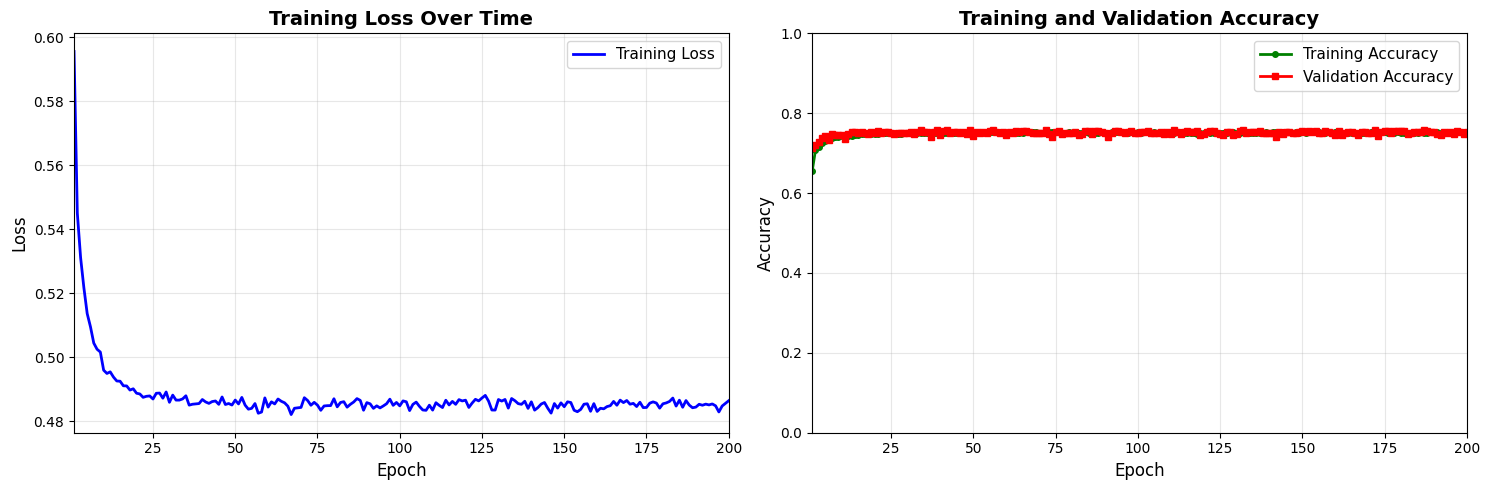


Training Summary
Total Epochs: 200
Final Training Loss: 0.4864
Final Training Accuracy: 0.7508
Final Validation Accuracy: 0.7518
Best Validation Accuracy: 0.7585 (Epoch 42)


In [51]:
# Extract training history
epochs = model.training_history['epochs']
train_loss = model.training_history['train_loss']
train_acc = model.training_history['train_acc']
val_acc = model.training_history['val_acc']

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training Loss
axes[0].plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_xlim([min(epochs), max(epochs)])

# Plot 2: Training and Validation Accuracy
axes[1].plot(epochs, train_acc, 'g-', linewidth=2, label='Training Accuracy', marker='o', markersize=4)
if val_acc:
    axes[1].plot(epochs, val_acc, 'r-', linewidth=2, label='Validation Accuracy', marker='s', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].set_xlim([min(epochs), max(epochs)])

plt.tight_layout()
plt.savefig('training_history_siamese.png')
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total Epochs: {len(epochs)}")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
if val_acc:
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"Best Validation Accuracy: {max(val_acc):.4f} (Epoch {epochs[val_acc.index(max(val_acc))]})")
print("="*50)
